# AlexNet: The Deep Learning Breakthrough (and Its Inefficiencies)

## Introduction

**AlexNet** (Krizhevsky et al., 2012) sparked the deep learning revolution by winning ImageNet 2012 with a 10% margin over traditional methods. It proved that deep CNNs could scale to complex real-world tasks.

**What made it work:**

1. **ReLU activation** - 6× faster training, no vanishing gradients
2. **Dropout** - Prevents overfitting in large networks
3. **Depth** - 5 convolutional layers vs LeNet's 2
4. **Capacity** - 64→192→384→256→256 filters vs LeNet's 6→16
5. **Data augmentation** - Random crops, flips, color jittering
6. **GPU training** - Made deep networks practical

**What we'll explore:**

- See how AlexNet solves each of LeNet's limitations
- Train on CIFAR-10 and compare performance
- **Identify AlexNet's own inefficiencies** that motivated VGG

**Why this matters:**

AlexNet showed that **scale works** - but it also revealed that we can be smarter about *how* we scale. Understanding its limitations motivates VGG's key insight: small filters are better.

## 1. Setup

### Import libraries

### Set random seed for reproducibility

In [ ]:
from aiml_notebooks import get_device, set_seed

In [2]:
set_seed(42)

### Configure device

In [3]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda


## 2. Recap: LeNet's Limitations

Before diving into AlexNet, let's recall what we need to fix:

| Problem | Impact |
|---------|--------|
| **Only 2 conv layers** | Can't learn hierarchical features |
| **6/16 filters** | Insufficient capacity for complex patterns |
| **tanh activation** | Vanishing gradients in deep networks |
| **No regularization** | Overfitting on complex tasks |
| **Large FC layers** | Most parameters, prone to overfitting |

AlexNet addresses **every single one** of these issues.

## 3. Dataset Preparation

We'll use CIFAR-10 (32×32 color images) for consistency with the LeNet notebook.

### Define data transforms

AlexNet introduced aggressive data augmentation - we'll use modern variants.

In [ ]:
from torchvision import datasets, transforms

In [4]:
# CIFAR-10 normalization statistics
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # AlexNet innovation
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

### Load CIFAR-10 dataset

In [5]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 50000
Test samples: 10000


### Create data loaders

In [ ]:
from torch.utils.data import DataLoader

In [6]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

## 4. AlexNet Architecture

### Original Design (2012)

**Architecture:**
- Input: 224×224 RGB (ImageNet)
- 5 conv layers: 96 → 256 → 384 → 384 → 256
- 3 FC layers: 4096 → 4096 → 1000
- **60M parameters**

**Key innovations:**
1. **ReLU instead of tanh** - Faster training, no saturation
2. **Dropout (0.5)** - Regularization in FC layers
3. **Local Response Normalization** - Inter-channel competition (less common now)
4. **Overlapping pooling** - 3×3 kernel with stride 2
5. **GPU parallelism** - Split across 2 GPUs

### Our Adaptation

Scaled for 32×32 CIFAR-10:
- Reduced filter sizes to match image resolution
- BatchNorm instead of LRN (modern practice)
- Smaller FC layers to reduce parameters

### Implement AlexNet

Notice: 5 conv layers (vs LeNet's 2) with much more capacity.

In [7]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        # Feature extraction: 5 convolutional layers
        self.features = nn.Sequential(
            # Conv1: 32x32x3 -> 32x32x64 -> 16x16x64
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),  # Innovation #1: ReLU!
            nn.MaxPool2d(2, 2),
            
            # Conv2: 16x16x64 -> 16x16x192 -> 8x8x192
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Conv3: 8x8x192 -> 8x8x384
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),
            
            # Conv4: 8x8x384 -> 8x8x256
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            # Conv5: 8x8x256 -> 8x8x256 -> 4x4x256
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        
        # Classification: 3 FC layers with dropout
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),  # Innovation #2: Dropout!
            nn.Linear(256 * 4 * 4, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(2048, 2048),
            nn.ReLU(inplace=True),
            nn.Linear(2048, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

### Inspect the architecture

In [8]:
model = AlexNet().to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"AlexNet Architecture:")
print(model)
print(f"\nParameter count:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")

# Test forward pass
dummy_input = torch.randn(1, 3, 32, 32).to(device)
output = model(dummy_input)
print(f"\nOutput shape: {output.shape}")

AlexNet Architecture:
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=Tr

### Compare to LeNet

Let's see how AlexNet addresses each limitation.

In [9]:
print("LeNet vs AlexNet Comparison:\n")
print(f"{'Metric':<25} {'LeNet':<15} {'AlexNet':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Convolutional layers':<25} {2:<15} {5:<15} {'+150%'}")
print(f"{'First layer filters':<25} {6:<15} {64:<15} {'+967%'}")
print(f"{'Second layer filters':<25} {16:<15} {192:<15} {'+1100%'}")
print(f"{'Total parameters':<25} {'~83K':<15} {f'{total_params//1000}K':<15} {f'+{total_params//83170}00%'}")
print(f"{'Activation function':<25} {'ReLU*':<15} {'ReLU':<15} {'Native'}")
print(f"{'Regularization':<25} {'None**':<15} {'Dropout':<15} {'✓'}")
print(f"{'Data augmentation':<25} {'Basic':<15} {'Aggressive':<15} {'✓'}")
print("\n* We used ReLU in LeNet adaptation (original used tanh)")
print("** We used BatchNorm in LeNet adaptation (original had none)")

LeNet vs AlexNet Comparison:

Metric                    LeNet           AlexNet         Improvement
----------------------------------------------------------------------
Convolutional layers      2               5               +150%
First layer filters       6               64              +967%
Second layer filters      16              192             +1100%
Total parameters          ~83K            14861K          +17800%
Activation function       ReLU*           ReLU            Native
Regularization            None**          Dropout         ✓
Data augmentation         Basic           Aggressive      ✓

* We used ReLU in LeNet adaptation (original used tanh)
** We used BatchNorm in LeNet adaptation (original had none)


## 5. Training

Let's train AlexNet and see if it outperforms LeNet.

### Define training utilities

In [ ]:
from tqdm.auto import tqdm

In [10]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': f'{running_loss/len(pbar):.3f}', 
                         'acc': f'{100.*correct/total:.2f}%'})
    
    return running_loss / len(train_loader), 100. * correct / total

def evaluate(model, test_loader, criterion, device):
    """Evaluate on test set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Evaluating'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(test_loader), 100. * correct / total

### Train the model

We'll train for 15 epochs to see AlexNet's full potential.

In [11]:
# Initialize model
model = AlexNet().to(device)

# Training configuration
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                       factor=0.5, patience=3)

# Training history
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

# Training loop
epochs = 15
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    scheduler.step(test_loss)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")


Epoch 1/15


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 1.8630 | Train Acc: 29.10%
Test Loss: 1.5020 | Test Acc: 43.19%

Epoch 2/15


Training:   0%|          | 0/391 [00:00<?, ?it/s]

...

^

AssertionError

: 

can only test a child process

Train Loss: 0.5040 | Train Acc: 83.13%
Test Loss: 0.5869 | Test Acc: 81.08%


## 6. Results and Analysis

### Plot training curves

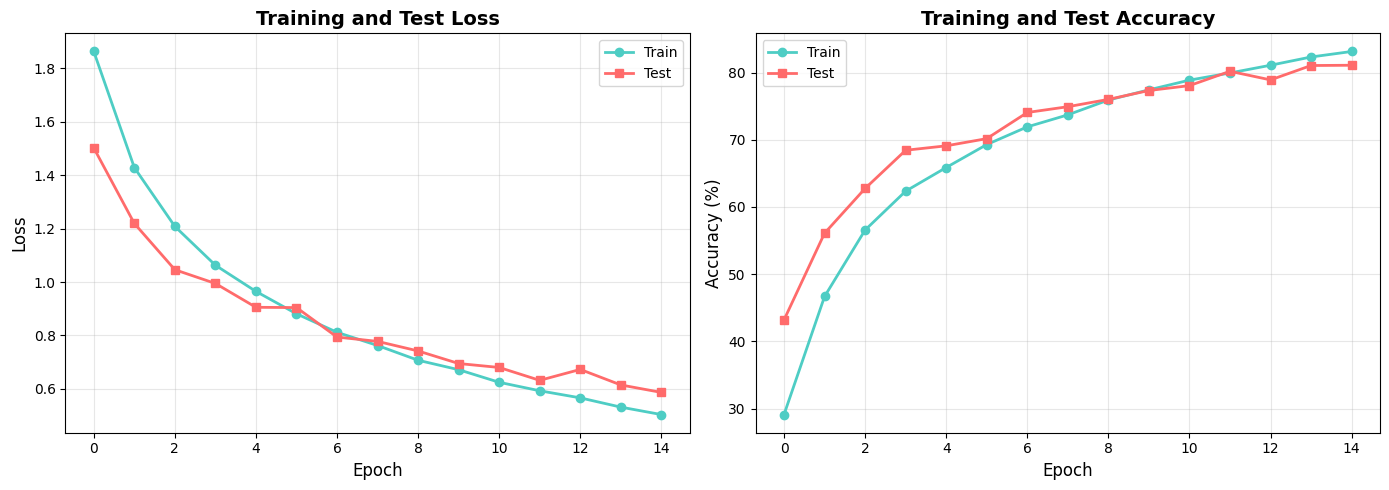


Final Results:
  Train Accuracy: 83.13%
  Test Accuracy: 81.08%
  Overfitting Gap: 2.05%


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(history['train_loss'], label='Train', marker='o', linewidth=2, color='#4ECDC4')
ax1.plot(history['test_loss'], label='Test', marker='s', linewidth=2, color='#FF6B6B')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Test Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(history['train_acc'], label='Train', marker='o', linewidth=2, color='#4ECDC4')
ax2.plot(history['test_acc'], label='Test', marker='s', linewidth=2, color='#FF6B6B')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Test Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"  Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"  Test Accuracy: {history['test_acc'][-1]:.2f}%")
print(f"  Overfitting Gap: {history['train_acc'][-1] - history['test_acc'][-1]:.2f}%")

### Visualize feature maps

Let's see how AlexNet's deeper layers learn richer features.

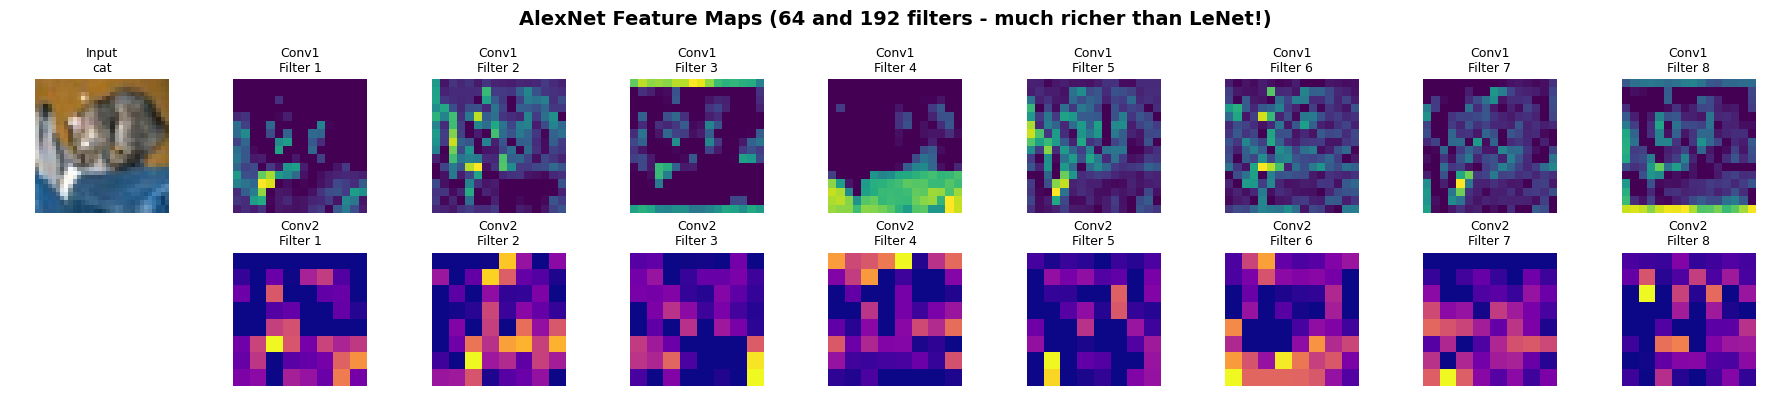

Conv1: 64 filters (vs LeNet's 6)
Conv2: 192 filters (vs LeNet's 16)


In [13]:
# Get a test image
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
test_img, test_label = test_dataset[0]
test_img_batch = test_img.unsqueeze(0).to(device)

# Extract features from different layers
model.eval()
with torch.no_grad():
    # Conv1 output (64 channels)
    conv1_out = model.features[:4](test_img_batch)  # Up to first pool
    # Conv2 output (192 channels)
    conv2_out = model.features[:8](test_img_batch)  # Up to second pool

# Visualize first 8 filters from Conv1 and Conv2
fig, axes = plt.subplots(2, 9, figsize=(18, 4))

# Original image
mean_tensor = torch.tensor(mean).view(3, 1, 1)
std_tensor = torch.tensor(std).view(3, 1, 1)
denorm_img = test_img * std_tensor + mean_tensor
axes[0, 0].imshow(denorm_img.clamp(0, 1).permute(1, 2, 0).numpy())
axes[0, 0].set_title(f'Input\n{classes[test_label]}', fontsize=9)
axes[0, 0].axis('off')

axes[1, 0].axis('off')  # Empty cell

# Conv1 features (64 channels, show 8)
for i in range(8):
    axes[0, i+1].imshow(conv1_out[0, i].cpu().numpy(), cmap='viridis')
    axes[0, i+1].set_title(f'Conv1\nFilter {i+1}', fontsize=9)
    axes[0, i+1].axis('off')

# Conv2 features (192 channels, show 8)
for i in range(8):
    axes[1, i+1].imshow(conv2_out[0, i].cpu().numpy(), cmap='plasma')
    axes[1, i+1].set_title(f'Conv2\nFilter {i+1}', fontsize=9)
    axes[1, i+1].axis('off')

plt.suptitle('AlexNet Feature Maps (64 and 192 filters - much richer than LeNet!)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Conv1: {conv1_out.shape[1]} filters (vs LeNet's 6)")
print(f"Conv2: {conv2_out.shape[1]} filters (vs LeNet's 16)")

## 7. AlexNet's Limitations

AlexNet was revolutionary, but it has significant inefficiencies that VGG addressed.

### Limitation 1: Large Filters Are Parameter-Inefficient

**Problem:** AlexNet uses 11×11 and 5×5 filters. These are expensive!

Let's calculate the parameter cost:

In [14]:
print("Filter Size Efficiency Analysis:\n")
print("Original AlexNet (ImageNet) first layer:")
print(f"  11×11 conv: 3 channels × 96 filters × 11 × 11 = {3*96*11*11:,} parameters")
print("\nCompare to VGG's approach:")
print(f"  Two 3×3 convs have same receptive field as one 5×5")
print(f"  Three 3×3 convs have same receptive field as one 7×7")
print("\nParameter comparison for 64 input/output channels:")
one_5x5 = 64 * 64 * 5 * 5
two_3x3 = 2 * (64 * 64 * 3 * 3)
print(f"  One 5×5 conv:  {one_5x5:,} params")
print(f"  Two 3×3 convs: {two_3x3:,} params")
print(f"  Savings: {100*(one_5x5-two_3x3)/one_5x5:.1f}%")
print("\n✅ VGG insight: Stack small filters instead of using large ones!")

Filter Size Efficiency Analysis:

Original AlexNet (ImageNet) first layer:
  11×11 conv: 3 channels × 96 filters × 11 × 11 = 34,848 parameters

Compare to VGG's approach:
  Two 3×3 convs have same receptive field as one 5×5
  Three 3×3 convs have same receptive field as one 7×7

Parameter comparison for 64 input/output channels:
  One 5×5 conv:  102,400 params
  Two 3×3 convs: 73,728 params
  Savings: 28.0%

✅ VGG insight: Stack small filters instead of using large ones!


### Limitation 2: Most Parameters in FC Layers

**Problem:** Just like LeNet, most of AlexNet's parameters are in fully-connected layers.

Let's analyze the distribution:

AlexNet Parameter Distribution:
  Convolutional layers:  2,253,888 ( 15.2%)
  Fully-connected:      12,607,498 ( 84.8%)
  Total:                14,861,386

⚠️  85% of parameters are in FC layers!
  This makes the model:
  • Memory-heavy during inference
  • Prone to overfitting (despite dropout)
  • Unable to handle variable input sizes


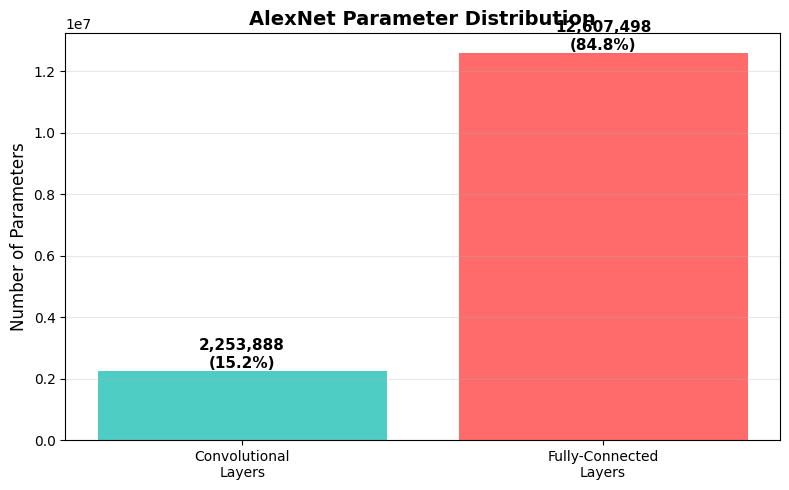

In [15]:
# Count parameters by layer type
conv_params = sum(p.numel() for name, p in model.named_parameters() 
                  if 'features' in name)
fc_params = sum(p.numel() for name, p in model.named_parameters() 
                if 'classifier' in name)
total = conv_params + fc_params

print(f"AlexNet Parameter Distribution:")
print(f"  Convolutional layers: {conv_params:>10,} ({100*conv_params/total:>5.1f}%)")
print(f"  Fully-connected:      {fc_params:>10,} ({100*fc_params/total:>5.1f}%)")
print(f"  Total:                {total:>10,}")
print(f"\n⚠️  {100*fc_params/total:.0f}% of parameters are in FC layers!")
print(f"  This makes the model:")
print(f"  • Memory-heavy during inference")
print(f"  • Prone to overfitting (despite dropout)")
print(f"  • Unable to handle variable input sizes")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Convolutional\nLayers', 'Fully-Connected\nLayers'], 
              [conv_params, fc_params], 
              color=['#4ECDC4', '#FF6B6B'])
ax.set_ylabel('Number of Parameters', fontsize=12)
ax.set_title('AlexNet Parameter Distribution', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}\n({100*height/total:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Limitation 3: Heterogeneous Architecture

**Problem:** AlexNet has different filter sizes and configurations per layer. This makes it:
- Harder to design (many hyperparameters)
- Harder to scale (which layers to add?)
- Less elegant than uniform architectures

In [16]:
print("AlexNet Layer Configuration:\n")
print("Our CIFAR-10 adaptation uses 3×3 throughout, but original AlexNet had:")
print("  Conv1: 11×11 kernel, stride 4")
print("  Conv2: 5×5 kernel")
print("  Conv3: 3×3 kernel")
print("  Conv4: 3×3 kernel")
print("  Conv5: 3×3 kernel")
print("\n⚠️  Many design choices to make:")
print("  • Which kernel sizes to use?")
print("  • When to use larger vs smaller kernels?")
print("  • How to scale the architecture?")
print("\n✅ VGG's solution: Use 3×3 everywhere! Simple and scalable.")

AlexNet Layer Configuration:

Our CIFAR-10 adaptation uses 3×3 throughout, but original AlexNet had:
  Conv1: 11×11 kernel, stride 4
  Conv2: 5×5 kernel
  Conv3: 3×3 kernel
  Conv4: 3×3 kernel
  Conv5: 3×3 kernel

⚠️  Many design choices to make:
  • Which kernel sizes to use?
  • When to use larger vs smaller kernels?
  • How to scale the architecture?

✅ VGG's solution: Use 3×3 everywhere! Simple and scalable.


### Limitation 4: No Deeper Stacking Strategy

**Problem:** AlexNet showed that depth helps (5 layers > 2 layers), but:
- Why stop at 5?
- How do we go deeper without exploding parameters?
- What's the optimal depth?

In [17]:
print("Depth Progression:")
print(f"  LeNet (1998):  2 conv layers")
print(f"  AlexNet (2012): 5 conv layers (+150%)")
print(f"  VGG-16 (2014):  13 conv layers (+160%)")
print(f"  VGG-19 (2014):  16 conv layers")
print(f"\n❓ Question: How deep can we go?")
print(f"  AlexNet didn't systematically explore depth")
print(f"  VGG showed: MUCH deeper with small filters")
print(f"  ResNet showed: 100+ layers with skip connections")

Depth Progression:
  LeNet (1998):  2 conv layers
  AlexNet (2012): 5 conv layers (+150%)
  VGG-16 (2014):  13 conv layers (+160%)
  VGG-19 (2014):  16 conv layers

❓ Question: How deep can we go?
  AlexNet didn't systematically explore depth
  VGG showed: MUCH deeper with small filters
  ResNet showed: 100+ layers with skip connections


## 8. Summary: AlexNet's Legacy and VGG's Improvements

### What AlexNet Got Right ✅

| Innovation | Impact |
|------------|--------|
| **ReLU activation** | 6× faster training, enabled depth |
| **Dropout** | Prevented overfitting in large networks |
| **Data augmentation** | Improved generalization |
| **GPU training** | Made deep learning practical |
| **Depth (5 layers)** | Proved hierarchical features scale |
| **Capacity (64→192→384)** | Showed networks need width |

**Result:** 15.3% error on ImageNet vs 26.2% for second place. Started the deep learning revolution.

---

### What VGG Improved 🎯

| AlexNet Problem | VGG Solution |
|-----------------|-------------|
| **Large filters (11×11, 5×5)** | Stack 3×3 filters (fewer params, more non-linearity) |
| **Heterogeneous design** | Uniform 3×3 architecture (simple, scalable) |
| **Unclear depth strategy** | Systematic exploration: VGG-11, 13, 16, 19 |
| **FC layer dominance** | Still has FC layers (later solved by Global Average Pooling) |

---

### Key Insights

1. **AlexNet proved scale works** - Deeper and wider networks perform better
2. **But scaling needs to be smart** - Small filters are more efficient than large ones
3. **Uniformity beats heterogeneity** - 3×3 everywhere is simpler and works better
4. **Depth is critical** - But we need the right building blocks to go deep

---

### What's Next?

In the **VGG notebook**, we'll see how the simple principle of "stack 3×3 filters deeply" leads to:
- Better parameter efficiency
- Clearer design principles
- State-of-the-art performance (2014)

And we'll discover VGG's own limitations that motivated Inception and ResNet!